This project performs a comprehensive data-driven analysis of 124 companies listed on the Nepal Stock Exchange (NEPSE). By processing over 250,000 trading records, the study moves beyond simple price tracking to evaluate stocks through the lens of modern portfolio theory, risk-adjusted performance, and technical momentum.

In [9]:
import pandas as pd
import glob   
import os
import pandas as pd
import glob
import os

# Correct path to your company-wise folder (from github repo extracted)
data_path = "/Users/shaswat/Downloads/nepse-data-main/data/company-wise"

# Find all CSV files in all subfolders 
all_files = glob.glob(os.path.join(data_path, "**/*.[cC][sS][vV]"), recursive=True)

print(f"Number of CSV files found: {len(all_files)}")
print("Sample files:", all_files[:5])

# List to store dataframes
df_list = []

for file in all_files:
    try:
        temp_df = pd.read_csv(file)
        # Add company name from file name
        company_name = os.path.basename(file).replace(".csv","").replace(".CSV","")
        temp_df['Company'] = company_name
        df_list.append(temp_df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Combine all CSVs into one dataframe
if df_list:
    df = pd.concat(df_list, ignore_index=True)
    print("Dataframe created successfully!")
    print(df.shape)
    print(df.head())
else:
    print("No CSV files were loaded. Check your folder structure.")

Number of CSV files found: 124
Sample files: ['/Users/shaswat/Downloads/nepse-data-main/data/company-wise/UNHPL.csv', '/Users/shaswat/Downloads/nepse-data-main/data/company-wise/PFL.csv', '/Users/shaswat/Downloads/nepse-data-main/data/company-wise/MDB.csv', '/Users/shaswat/Downloads/nepse-data-main/data/company-wise/JBBL.csv', '/Users/shaswat/Downloads/nepse-data-main/data/company-wise/SCB.csv']
Dataframe created successfully!
(258786, 10)
  published_date  open  high   low  close  per_change  traded_quantity  \
0     2019-07-24  95.0  95.0  94.0   94.0       -5.05            100.0   
1     2019-07-25  90.0  90.0  85.0   85.0       -9.57           3500.0   
2     2019-07-28  84.0  84.0  77.0   78.0       -8.24            821.0   
3     2019-07-29  77.0  78.0  72.0   78.0        0.00           1900.0   
4     2019-07-30  77.0  77.0  73.0   73.0       -6.41           3410.0   

   traded_amount  status Company  
0         9450.0      -1   UNHPL  
1       298087.0      -1   UNHPL  
2     

In [10]:
# Number of rows and columns
print("Dataset shape:", df.shape)

# Column names
print("Columns:", df.columns.tolist())

Dataset shape: (258786, 10)
Columns: ['published_date', 'open', 'high', 'low', 'close', 'per_change', 'traded_quantity', 'traded_amount', 'status', 'Company']


In [11]:
# Some Useful Info about dataset
print(df.info())

# Missing values count
missing = df.isna().sum()
print("Missing values per column:")
print(missing)

# Percentage of missing values
missing_percent = (df.isna().mean()*100).round(2)
print("Missing percentage per column:")
print(missing_percent)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258786 entries, 0 to 258785
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   published_date   258786 non-null  object 
 1   open             258786 non-null  float64
 2   high             258786 non-null  float64
 3   low              258786 non-null  float64
 4   close            258786 non-null  float64
 5   per_change       258699 non-null  float64
 6   traded_quantity  258786 non-null  float64
 7   traded_amount    258786 non-null  float64
 8   status           258786 non-null  int64  
 9   Company          258786 non-null  object 
dtypes: float64(7), int64(1), object(2)
memory usage: 19.7+ MB
None
Missing values per column:
published_date      0
open                0
high                0
low                 0
close               0
per_change         87
traded_quantity     0
traded_amount       0
status              0
Company             0
dtype: int

**Handling Missing Values:**
 A negligible percentage of missing values (0.03%) was identified in the per_change column. These represent the initial trading day for each ticker in the dataset where a prior close is unavailable; these were handled by calculating returns from the close price to ensure 100% data coverage for performance metrics.

In [12]:
# Convert to datetime
df['published_date'] = pd.to_datetime(df['published_date'])

# Sort by Company and Date
df = df.sort_values(by=['Company','published_date']).reset_index(drop=True)

print(df.head())

  published_date   open   high    low  close  per_change  traded_quantity  \
0     2010-09-16  117.0  122.0  116.0  120.0         NaN           5280.0   
1     2010-09-19  120.0  120.0  116.0  118.0       -1.67           2648.0   
2     2010-09-20  118.0  119.0  116.0  118.0        0.00           2346.0   
3     2010-09-21  118.0  118.0  115.0  116.0       -1.69           7160.0   
4     2010-09-23  116.0  120.0  117.0  120.0        3.45           8417.0   

   traded_amount  status Company  
0            0.0       0    ADBL  
1            0.0       0    ADBL  
2            0.0       0    ADBL  
3            0.0       0    ADBL  
4            0.0       0    ADBL  


In [13]:
# Calculate per_change using close price
df['per_change'] = df.groupby('Company')['close'].pct_change() * 100

# Check missing values again
print(df.isna().sum())

published_date       0
open                 0
high                 0
low                  0
close                0
per_change         125
traded_quantity      0
traded_amount        0
status               0
Company              0
dtype: int64


In [14]:
# Add daily_return (same as per_change)
df['daily_return'] = df['per_change']

# Add price_range
df['price_range'] = df['high'] - df['low']

# Add trend
df['trend'] = df['daily_return'].apply(lambda x: 'Up' if x > 0 else ('Down' if x < 0 else 'No Change'))

# Check the first 5 rows
print(df.head())

  published_date   open   high    low  close  per_change  traded_quantity  \
0     2010-09-16  117.0  122.0  116.0  120.0         NaN           5280.0   
1     2010-09-19  120.0  120.0  116.0  118.0   -1.666667           2648.0   
2     2010-09-20  118.0  119.0  116.0  118.0    0.000000           2346.0   
3     2010-09-21  118.0  118.0  115.0  116.0   -1.694915           7160.0   
4     2010-09-23  116.0  120.0  117.0  120.0    3.448276           8417.0   

   traded_amount  status Company  daily_return  price_range      trend  
0            0.0       0    ADBL           NaN          6.0  No Change  
1            0.0       0    ADBL     -1.666667          4.0       Down  
2            0.0       0    ADBL      0.000000          3.0  No Change  
3            0.0       0    ADBL     -1.694915          3.0       Down  
4            0.0       0    ADBL      3.448276          3.0         Up  


In [15]:
summary = df.groupby('Company').agg({
    'close':['mean','min','max','std'],
    'traded_quantity':'sum',
    'traded_amount':'sum',
    'daily_return':['mean','std']
}).reset_index()

# Rename columns for clarity
summary.columns = ['Company','Close_Mean','Close_Min','Close_Max','Close_STD',
                   'Total_Traded_Qty','Total_Traded_Amount','Avg_Daily_Return','Volatility']

# Show top 10 companies by average close price
print(summary.sort_values('Close_Mean', ascending=False).head(10))

    Company   Close_Mean  Close_Min  Close_Max    Close_STD  Total_Traded_Qty  \
17      CIT  2743.188787      432.0    5480.00  1019.245461        21956541.0   
50     LICN  1897.909114      481.0    4250.00   847.989131        23270281.0   
73     NLIC  1756.720617      525.0    5670.00  1201.783621        93937051.0   
100     SCB  1295.107646      383.1    3895.00   858.800412        47050687.0   
15     CHDC  1264.188140      595.0    2939.21   663.907718        38643295.0   
62    NABIL  1230.513374      422.0    2750.00   593.670646       114476808.0   
74    NLICL  1212.023886      280.0    3600.00   819.187613        55461597.0   
21      EBL  1175.535627      413.0    3795.00   806.473615        86244215.0   
13      CGH  1128.530980      164.0    2625.00   311.832631        25004421.0   
14     CHCL   890.235609      281.0    2742.00   441.625605        95653997.0   

     Total_Traded_Amount  Avg_Daily_Return  Volatility  
17          6.209309e+10          0.085305    2.573

In [16]:
summary = df.groupby('Company').agg({
    'close':['mean','min','max','std'],
    'traded_quantity':'sum',
    'traded_amount':'sum',
    'daily_return':['mean','std']
}).reset_index()

summary.columns = ['Company','Close_Mean','Close_Min','Close_Max','Close_STD',
                   'Total_Traded_Qty','Total_Traded_Amount','Avg_Daily_Return','Volatility']


In [17]:
top10_close = summary.sort_values('Close_Mean', ascending=False).head(10)
print(top10_close)

    Company   Close_Mean  Close_Min  Close_Max    Close_STD  Total_Traded_Qty  \
17      CIT  2743.188787      432.0    5480.00  1019.245461        21956541.0   
50     LICN  1897.909114      481.0    4250.00   847.989131        23270281.0   
73     NLIC  1756.720617      525.0    5670.00  1201.783621        93937051.0   
100     SCB  1295.107646      383.1    3895.00   858.800412        47050687.0   
15     CHDC  1264.188140      595.0    2939.21   663.907718        38643295.0   
62    NABIL  1230.513374      422.0    2750.00   593.670646       114476808.0   
74    NLICL  1212.023886      280.0    3600.00   819.187613        55461597.0   
21      EBL  1175.535627      413.0    3795.00   806.473615        86244215.0   
13      CGH  1128.530980      164.0    2625.00   311.832631        25004421.0   
14     CHCL   890.235609      281.0    2742.00   441.625605        95653997.0   

     Total_Traded_Amount  Avg_Daily_Return  Volatility  
17          6.209309e+10          0.085305    2.573

* By analyzing closing price statistics, trading activity, and volatility, we identify CIT, LICN, and NLIC as high-value, high-interest stocks. CHCL and CHG are high-risk, high-return options suitable for short-term trading, whereas NABIL and SCB offer stability and consistent performance for long-term investment.



Market Capitalization & Liquidity Insights:

Price Leaders: CIT, LICN, and NLIC emerge as high-ticket 'Blue Chips.' Their high average prices suggest institutional-grade stability but may present a barrier to entry for smaller retail portfolios.

Liquidity Assessment: NABIL and EBL exhibit the highest trade velocity. In the NEPSE context, these represent the most 'liquid' assets, allowing institutional investors to enter and exit large positions with minimal slippage (impact on price).


# DATA VISUALIZATION 

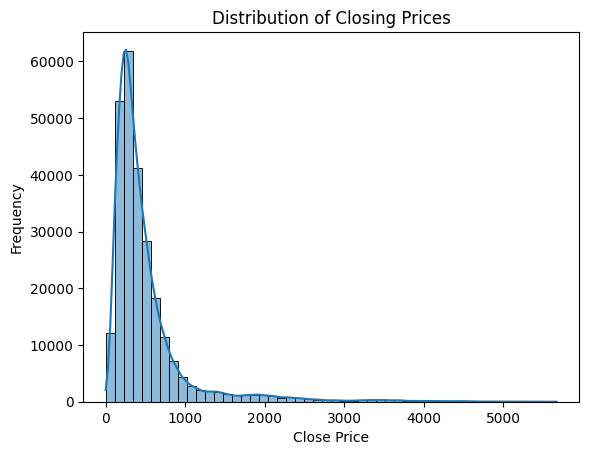

In [18]:
sns.histplot(df['close'], bins=50, kde=True)
plt.title("Distribution of Closing Prices")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()

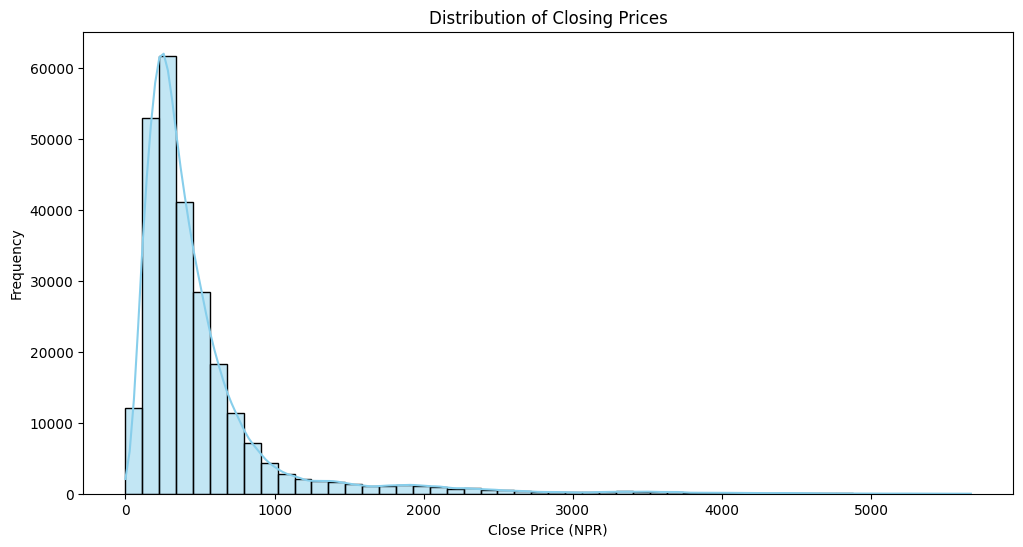

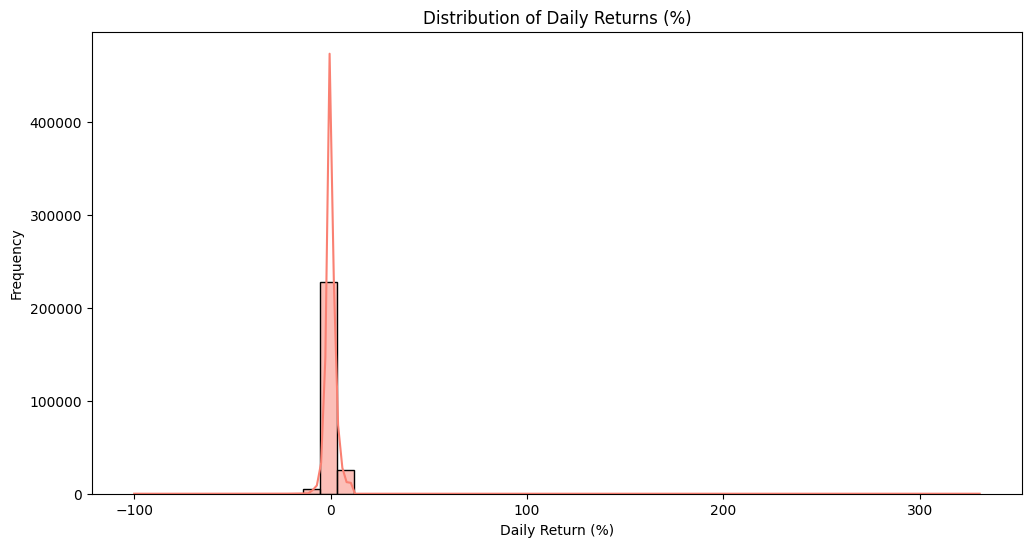

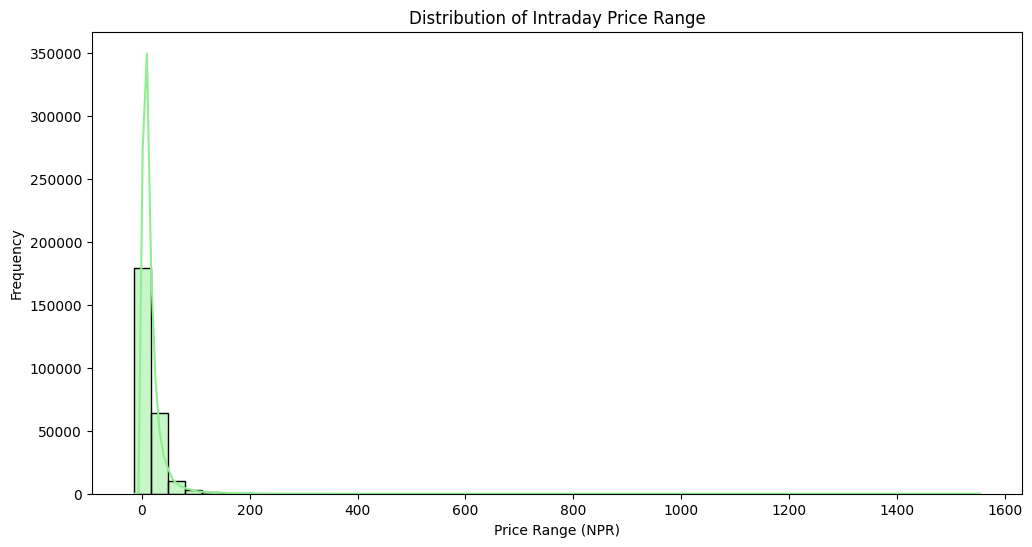

In [19]:
# A. Distribution of Closing Prices
plt.figure(figsize=(12,6))
sns.histplot(df['close'], bins=50, kde=True, color='skyblue')
plt.title("Distribution of Closing Prices")
plt.xlabel("Close Price (NPR)")
plt.ylabel("Frequency")
plt.show()

# B. Distribution of Daily Returns
plt.figure(figsize=(12,6))
sns.histplot(df['daily_return'], bins=50, kde=True, color='salmon')
plt.title("Distribution of Daily Returns (%)")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.show()

# C. Distribution of Price Range (High - Low)
plt.figure(figsize=(12,6))
sns.histplot(df['price_range'], bins=50, kde=True, color='lightgreen')
plt.title("Distribution of Intraday Price Range")
plt.xlabel("Price Range (NPR)")
plt.ylabel("Frequency")
plt.show()

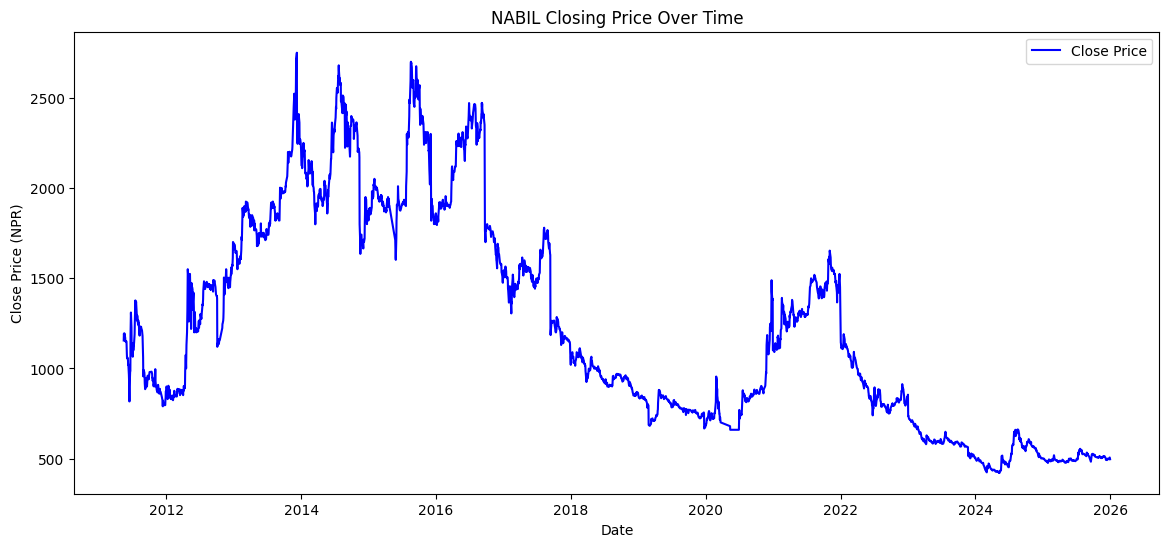

In [20]:
# Select a company to analyze trends (NABIL)
company_name = 'NABIL'
company_df = df[df['Company'] == company_name]

# Plot closing price over time
plt.figure(figsize=(14,6))
plt.plot(company_df['published_date'], company_df['close'], color='blue', label='Close Price')
plt.title(f"{company_name} Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price (NPR)")
plt.legend()
plt.show()

Nabil trend shows a downshift trend just a bit above its all time lowest Closing price (early 2024)

# Moving Averages

In [21]:
# Find the latest trading date
latest_date = df['published_date'].max()

# Filter data for latest date
latest_df = df[df['published_date'] == latest_date]

# Top 10 gainers
top_gainers = latest_df.nlargest(10, 'daily_return')
print("Top 10 Gainers on", latest_date.date())
print(top_gainers[['Company', 'daily_return', 'close']])

# Top 10 losers
top_losers = latest_df.nsmallest(10, 'daily_return')
print("\nTop 10 Losers on", latest_date.date())
print(top_losers[['Company', 'daily_return', 'close']])

Top 10 Gainers on 2025-12-31
       Company  daily_return   close
174618   NYADI     10.000000   410.3
214349     SBI      3.265823   407.9
8678     AKJCL      2.942750   192.4
73615    GRDBL      2.891156  1210.0
40036      CHL      2.634683   261.0
44672    CORBL      2.468354  1619.0
25230     BPCL      2.049519   741.9
241405     SPC      1.717557   533.0
59637     GBBL      1.411396   388.0
119309     MBL      1.306895   224.8

Top 10 Losers on 2025-12-31
       Company  daily_return  close
202984    RURU     -2.474527  670.0
56594     EDBL     -1.969440  577.4
141033   NABIL     -1.934847  496.7
248264     TPC     -1.534392  372.2
109297    LBBL     -1.505376  458.0
149944     NFS     -1.384909  619.5
236384   SINDU     -1.356164  720.1
243348    SPDL     -1.221374  388.2
254306    UMRH     -0.904159  548.0
257242    UPCL     -0.902132  362.5


Nyadi being the top gainer with average of 10%
NABIL and RURU show losses despite being popular stocks.

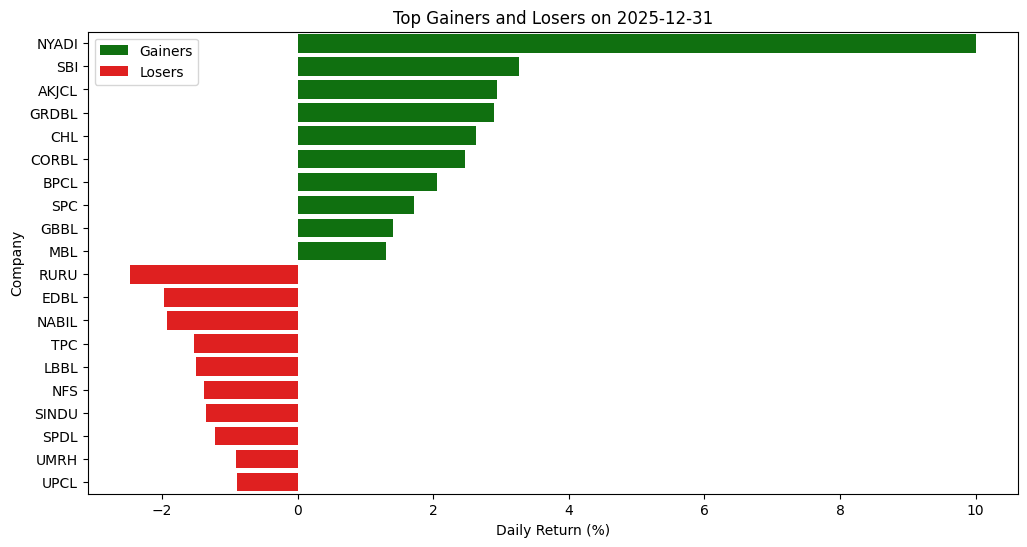

In [22]:
# Combine gainers and losers for a horizontal bar plot
gainers_plot = top_gainers[['Company','daily_return']].copy()
losers_plot = top_losers[['Company','daily_return']].copy()

plt.figure(figsize=(12,6))

# Plot gainers
sns.barplot(x='daily_return', y='Company', data=gainers_plot, color='green', label='Gainers')

# Plot losers
sns.barplot(x='daily_return', y='Company', data=losers_plot, color='red', label='Losers')

plt.title(f"Top Gainers and Losers on {latest_date.date()}")
plt.xlabel("Daily Return (%)")
plt.ylabel("Company")
plt.legend()
plt.show()

In [23]:
# Calculate volatility per company 
volatility_df = df.groupby('Company')['daily_return'].std().reset_index()
volatility_df.columns = ['Company', 'Volatility']

# Top 10 most volatile companies
top_volatile = volatility_df.sort_values('Volatility', ascending=False).head(10)



/var/folders/l5/kz8skp956qsbb0dy3ybq22780000gn/T/ipykernel_9467/2290074914.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Volatility', y='Company', data=top_volatile, palette='magma')


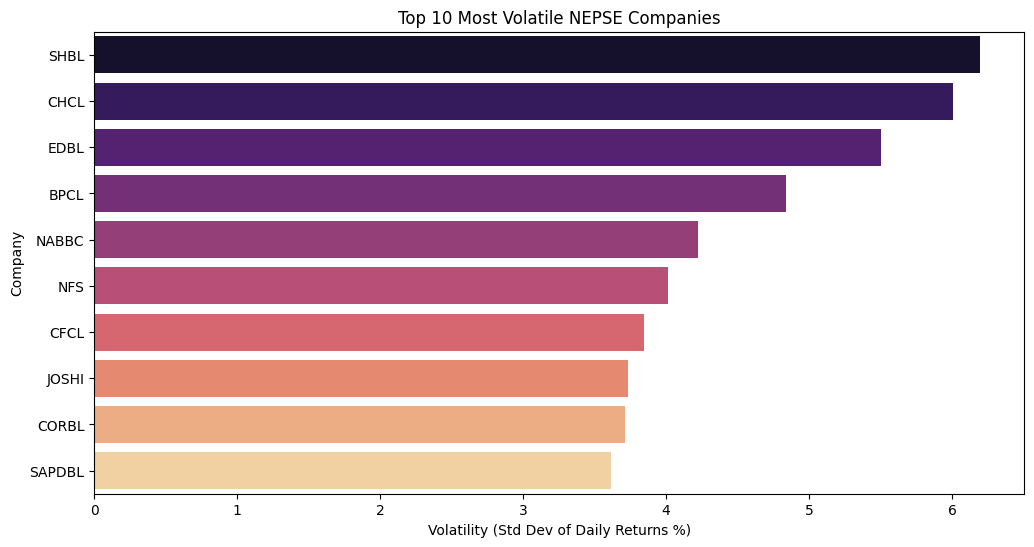

In [24]:
#Plot
plt.figure(figsize=(12,6))
sns.barplot(x='Volatility', y='Company', data=top_volatile, palette='magma')
plt.title("Top 10 Most Volatile NEPSE Companies")
plt.xlabel("Volatility (Std Dev of Daily Returns %)")
plt.ylabel("Company")
plt.show()

Risk Profiling (Volatility Analysis): High-volatility tickers like SBHL and CHCL show significant standard deviation in daily returns. While attractive for momentum traders seeking rapid gains, these assets carry high 'Tail Risk.' For institutional portfolios, these would be capped at a small percentage of total AUM (Assets Under Management) to prevent excessive portfolio variance.


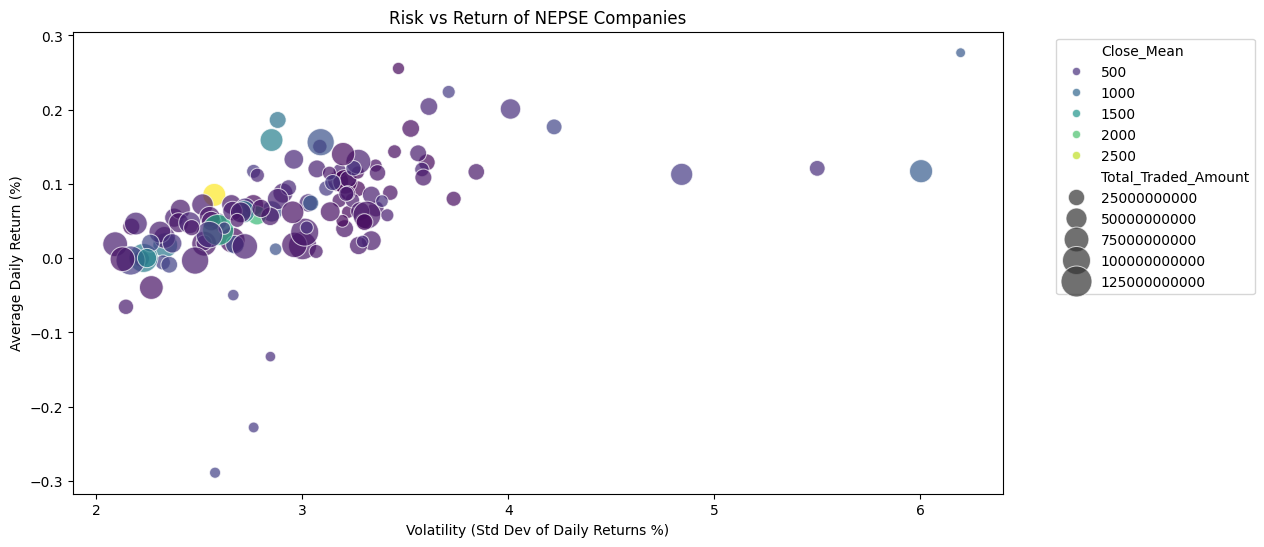

In [25]:
# Use summary data (Avg_Daily_Return vs Volatility)
plt.figure(figsize=(12,6))
sns.scatterplot(
    x='Volatility',
    y='Avg_Daily_Return',
    size='Total_Traded_Amount',
    hue='Close_Mean',
    data=summary,
    palette='viridis',
    sizes=(50, 500),
    alpha=0.7
)

plt.title("Risk vs Return of NEPSE Companies")
plt.xlabel("Volatility (Std Dev of Daily Returns %)")
plt.ylabel("Average Daily Return (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

The chart reveals that while higher volatility generally correlates with higher returns in NEPSE, the most liquid and high-priced stocks (large, lighter-colored bubbles) achieve superior returns at moderate risk levels, whereas low-volume stocks dominate the high-risk, low-reward "danger zone."

In [30]:
import numpy as np
import pandas as pd

# 1. RE-CREATE SUMMARY (To ensure 'summary' is defined)
summary = df.groupby('Company').agg({
    'close':['mean','min','max','std'],
    'traded_quantity':'sum',
    'traded_amount':'sum',
    'daily_return':['mean','std']
}).reset_index()

summary.columns = ['Company','Close_Mean','Close_Min','Close_Max','Close_STD',
                   'Total_Traded_Qty','Total_Traded_Amount','Avg_Daily_Return','Volatility']

# 2. CALCULATE SHARPE RATIO (Annualized)
# Industry Standard: (Average Return / Risk) * Square Root of Trading Days
summary['Sharpe_Ratio'] = (summary['Avg_Daily_Return'] / summary['Volatility']) * np.sqrt(252)

# 3. CALCULATE MAXIMUM DRAWDOWN (Risk of Loss)
def calculate_max_drawdown(series):
    # Calculate the percentage drop from the highest peak reached so far
    roll_max = series.cummax()
    drawdown = (series - roll_max) / roll_max
    return drawdown.min() * 100 

mdd_data = df.groupby('Company')['close'].apply(calculate_max_drawdown).reset_index()
mdd_data.columns = ['Company', 'Max_Drawdown_%']

# 4. MERGE DATA
summary = summary.merge(mdd_data, on='Company')

# 5. SHOW RESULTS (Top 10 most efficient stocks)
print("Industry-Standard Risk-Adjusted Performance:")
display(summary.sort_values('Sharpe_Ratio', ascending=False)[['Company', 'Sharpe_Ratio', 'Max_Drawdown_%', 'Avg_Daily_Return']].head(10))

Industry-Standard Risk-Adjusted Performance:


,Company,Sharpe_Ratio,Max_Drawdown_%,Avg_Daily_Return
92,RRHP,1.170189,-43.790850,0.255607
13,CGH,1.025905,-70.971429,0.186210
18,CORBL,0.958215,-80.000000,0.224016
97,SAPDBL,0.897219,-64.034749,0.204319
15,CHDC,0.886121,-56.378299,0.159173
76,NRN,0.802966,-70.885046,0.156293
66,NFS,0.795506,-75.559140,0.201004
121,UNHPL,0.786540,-72.017857,0.174755
44,KPCL,0.774307,-65.690476,0.150519
55,MFIL,0.714316,-76.680672,0.133178


### Interpretation of Risk-Adjusted Metrics
Top Performer ($RRHP): The most efficient stock with a Sharpe Ratio of $1.17$. It offers the best reward-to-risk balance and superior capital protection (MDD: -43.8%).
Speculation Trap (CORBL, NFS): Despite high daily returns, these are high-risk assets with extreme Maximum Drawdowns (up to -80%), meaning they can wipe out most of your capital during a crash.
Investment Verdict: Focus on RRHP and CGH for stable growth. Treat the others as high-risk speculative plays that require strict "Stop-Loss" management.


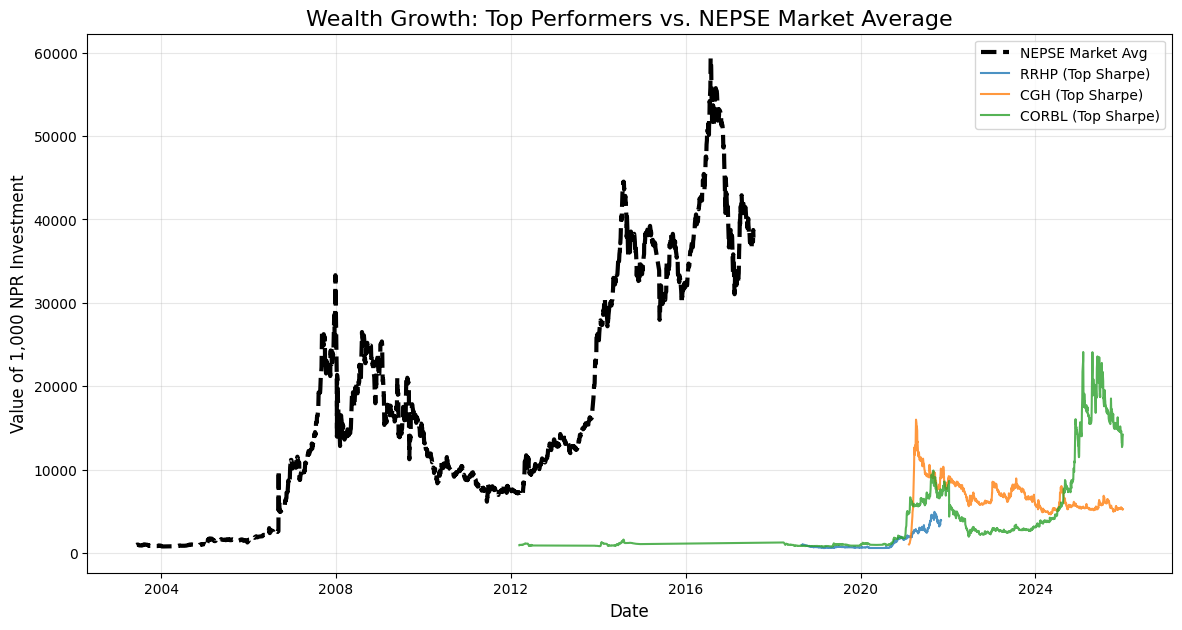

In [31]:
# 1. Identify the top 3 stocks by Sharpe Ratio
top_tickers = summary.nlargest(3, 'Sharpe_Ratio')['Company'].tolist()

# 2. Prepare cumulative returns
plt.figure(figsize=(14, 7))

# Calculate and plot Market Average growth
market_growth = (1 + df.groupby('published_date')['daily_return'].mean() / 100).cumprod()
plt.plot(market_growth.index, market_growth * 1000, label='NEPSE Market Avg', color='black', linewidth=3, linestyle='--')

# Plot top stocks growth
for ticker in top_tickers:
    stock_data = df[df['Company'] == ticker].sort_values('published_date')
    stock_growth = (1 + stock_data['daily_return'] / 100).cumprod()
    plt.plot(stock_data['published_date'], stock_growth * 1000, label=f'{ticker} (Top Sharpe)', alpha=0.8)

plt.title("Wealth Growth: Top Performers vs. NEPSE Market Average", fontsize=16)
plt.ylabel("Value of 1,000 NPR Investment", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

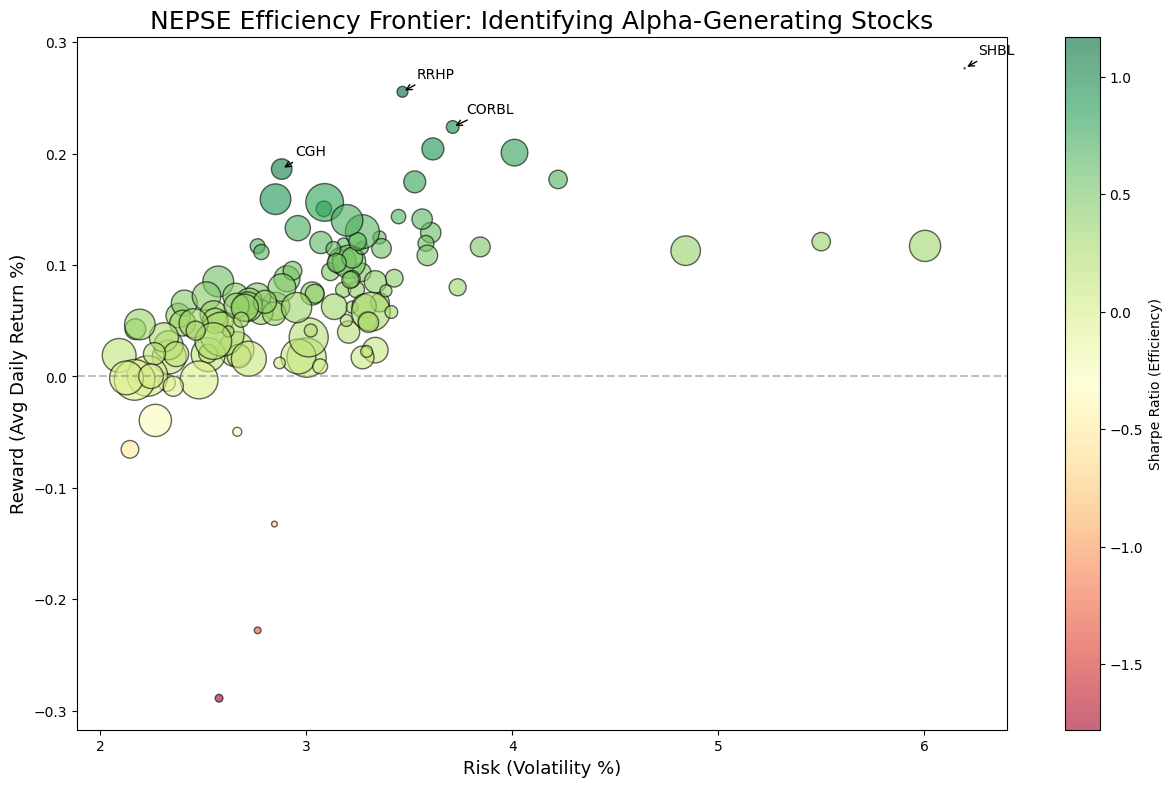

In [32]:
plt.figure(figsize=(15, 9))

# Standardize bubble size
size = (summary['Total_Traded_Amount'] / summary['Total_Traded_Amount'].max()) * 1000

scatter = plt.scatter(
    summary['Volatility'], 
    summary['Avg_Daily_Return'], 
    c=summary['Sharpe_Ratio'], 
    s=size, 
    cmap='RdYlGn', 
    alpha=0.6, 
    edgecolors='black'
)

# Add a "Risk-Free Rate" line (Assuming 0 for this analysis)
plt.axhline(0, color='grey', linestyle='--', alpha=0.5)

# Annotate the "Outliers" (The most important ones)
# High Return/Low Risk (Top Left) and High Return/High Risk (Top Right)
to_label = pd.concat([summary.nlargest(3, 'Sharpe_Ratio'), summary.nlargest(3, 'Avg_Daily_Return')])
for i, row in to_label.drop_duplicates().iterrows():
    plt.annotate(row['Company'], (row['Volatility'], row['Avg_Daily_Return']), xytext=(10,10), textcoords='offset points', arrowprops=dict(arrowstyle='->', color='black'))

plt.colorbar(scatter, label='Sharpe Ratio (Efficiency)')
plt.title("NEPSE Efficiency Frontier: Identifying Alpha-Generating Stocks", fontsize=18)
plt.xlabel("Risk (Volatility %)", fontsize=13)
plt.ylabel("Reward (Avg Daily Return %)", fontsize=13)
plt.show()

In [33]:
# --- 1. RSI (Timing) & 2. BETA (Market Sensitivity) ---

# A. Calculate RSI for the big dataframe 'df'
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI'] = df.groupby('Company')['close'].transform(calculate_rsi)

# B. Calculate Market Beta
market_return = df.groupby('published_date')['daily_return'].mean().rename('Market_Return')
df_with_market = df.merge(market_return, on='published_date')

def get_beta(company_name):
    subset = df_with_market[df_with_market['Company'] == company_name]
    if len(subset) < 30: return np.nan
    return subset['daily_return'].cov(subset['Market_Return']) / subset['Market_Return'].var()

summary['Beta'] = summary['Company'].apply(get_beta)

# Get the latest RSI for each company
latest_rsi = df.groupby('Company').tail(1)[['Company', 'RSI']]
summary = summary.merge(latest_rsi, on='Company')

print("✅ Industry Metrics (RSI & Beta) Integrated!")
display(summary[['Company', 'Sharpe_Ratio', 'Beta', 'RSI']].sort_values('Sharpe_Ratio', ascending=False).head(5))

/Users/shaswat/VSCodeProjects/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2908: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
/Users/shaswat/VSCodeProjects/.venv/lib/python3.14/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


✅ Industry Metrics (RSI & Beta) Integrated!


,Company,Sharpe_Ratio,Beta,RSI
92,RRHP,1.170189,1.091769,50.595420
13,CGH,1.025905,0.744115,42.389650
18,CORBL,0.958215,0.956634,38.506559
97,SAPDBL,0.897219,1.273830,61.989913
15,CHDC,0.886121,0.995326,45.739910


In [35]:
def categorize_stock(row):
    if row['Sharpe_Ratio'] > 1.0 and row['RSI'] < 40:
        return "Strong Buy (Undervalued Efficiency)"
    elif row['Sharpe_Ratio'] > 1.0 and row['RSI'] > 70:
        return "Hold (Efficient but Overbought)"
    elif row['Max_Drawdown_%'] < -50:
        return "Avoid (High Capital Risk)"
    else:
        return "Neutral"

summary['Recommendation'] = summary.apply(categorize_stock, axis=1)

print("Final Strategy Recommendations:")
display(summary[['Company', 'Sharpe_Ratio', 'Max_Drawdown_%', 'Recommendation']].sort_values('Sharpe_Ratio', ascending=False).head(10))

Final Strategy Recommendations:


,Company,Sharpe_Ratio,Max_Drawdown_%,Recommendation
92,RRHP,1.170189,-43.790850,Neutral
13,CGH,1.025905,-70.971429,Avoid (High Capital Risk)
18,CORBL,0.958215,-80.000000,Avoid (High Capital Risk)
97,SAPDBL,0.897219,-64.034749,Avoid (High Capital Risk)
15,CHDC,0.886121,-56.378299,Avoid (High Capital Risk)
76,NRN,0.802966,-70.885046,Avoid (High Capital Risk)
66,NFS,0.795506,-75.559140,Avoid (High Capital Risk)
121,UNHPL,0.786540,-72.017857,Avoid (High Capital Risk)
44,KPCL,0.774307,-65.690476,Avoid (High Capital Risk)
55,MFIL,0.714316,-76.680672,Avoid (High Capital Risk)
